# Week 7: Advanced numerical analysis: linear algebra and model fitting

## 7.2. Linear algebra with module numpy.linalg

### Question 7.1 : Linear algebra exercises

In [21]:
import numpy as np
from numpy import linalg as la
# We want to suppress printing of small floating point values using scientific notation 
np.set_printoptions(suppress=True)

# Calculating the matrix A
M = np.array([1,2,3,  0,-4,1, 0,3,-1]).reshape(3,3)
print("M=")
print(M)


M=
[[ 1  2  3]
 [ 0 -4  1]
 [ 0  3 -1]]
Determinant of A is: 1.000000


In [22]:
# 1) What is the determinant of A? 
det = la.det(M)
print(f"Determinant of A is: {det:.6f}")

Determinant of A is: 1.000000


In [23]:
# 2) What is the solution (x, y, z) of the following set of equations?
# x+2y+3z=2
#  -4y+z=2
#  +3y-z=-1

# the system of equations is of a matrix A anf a columns vector b
A = np.array([1,2,3,0,-4,1,0,3,-1]).reshape(3,3)
b = np.array([2, 1, -1])
print('The previuos system of equations can be expressed as the multiplication of matrix A by column vector b')
print('Given A:                         and b:', b)
print(A)                     
print()
X = la.solve(A, b)  # Unpacking is also possible with NumPy arrays
print(A, ".(x,y,z) =", X)
x, y, z = X         # Unpack tuple  
print(f"\nSolution (x, y, z) =({x:.6f}, {y:.6f}, {z:.6f})")

The previuos system of equations can be expressed as the multiplication of matrix A by column vector b
Given A:                         and b: [ 2  1 -1]
[[ 1  2  3]
 [ 0 -4  1]
 [ 0  3 -1]]

[[ 1  2  3]
 [ 0 -4  1]
 [ 0  3 -1]] .(x,y,z) = [-1. -0.  1.]

Solution (x, y, z) =(-1.000000, -0.000000, 1.000000)


In [57]:
import numpy as np
from numpy import linalg as la
from numpy.linalg import inv

# 3) Is A orthogonal?
print(f"Matrix A:\n{A}")
print(f"\nA.AT should be the identity matrix:\n{A@A.T}\n{A@A.T == np.identity(3)}")
print(f"\nInverse of A:\n{inv(A)}")
print(f"\nis not equal to the transpose:\n{A.T}")
print(f"\nAlternative check with function array_equal(): {np.array_equal(A.T, inv(A))}")
print(f"\nAlternative check with function allclose(): {np.allclose(A.T, inv(A))}")
print("\nSOLUTION: A is not orthogonal")

Matrix A:
[[ 1  2  3]
 [ 0 -4  1]
 [ 0  3 -1]]

A.AT should be the identity matrix:
[[ 14  -5   3]
 [ -5  17 -13]
 [  3 -13  10]]
[[False False False]
 [False False False]
 [False False False]]

Inverse of A:
[[ 1. 11. 14.]
 [-0. -1. -1.]
 [-0. -3. -4.]]

is not equal to the transpose:
[[ 1  0  0]
 [ 2 -4  3]
 [ 3  1 -1]]

Alternative check with function array_equal(): False

Alternative check with function allclose(): False

SOLUTION: A is not orthogonal


In [38]:
# 4) Give eigen values of A
# Eigen vectors v satisfy: A@v = lambda*v
# eigen values is the lambda
Lambda, v = la.eig(A)
print("Lambda = ", Lambda)

Lambda =  [ 1.         -4.79128785 -0.20871215]


### Question 7.3 : Applying a rotation matrix

In [5]:
import numpy as np
from numpy import linalg as la
from numpy.linalg import inv


# 1) CREATE COMPOSED MATRIX E FROM EQUATION
# RESULT: 
#               [[-0.06698874 -0.87275577 -0.48353891]
#               [ 0.49272847 -0.45034696  0.74458463]
#               [-0.86760081 -0.1883746   0.46019978]]

# Defining alpha, beta and gamma (a, b, g)
alpha = 180-123
beta = 90-27.4
gamma = 192.25

a = np.radians(alpha)
b = np.radians(beta)
g = np.radians(gamma)

# Defining Rz1, Ry and Rz2
Rz1 = np.array([np.cos(a),-np.sin(a),0 ,  np.sin(a),np.cos(a),0,  0,0,1]).reshape(3,3)
Ry = np.array([np.cos(b),0,np.sin(b),  0,1,0,  -np.sin(b),0, np.cos(b)]).reshape(3,3)
Rz2 = np.array([np.cos(g),-np.sin(g),0 ,  np.sin(g),np.cos(g),0,  0,0,1]).reshape(3,3)

# Calculate E
E = Rz1@Ry@Rz2
print('E is:\n',E)x+

E is:
 [[-0.06698874  0.87275577  0.48353891]
 [-0.49272847 -0.45034696  0.74458463]
 [ 0.86760081 -0.1883746   0.46019978]]


In [2]:
import numpy as np
from numpy import linalg as la
from numpy.linalg import inv

# 2) PROVE THAT COMPOSED MATRIX IS A ROTATION MATRIX

# Proving if determinant is 1
det = la.det(E)
print(f'The det(E):{det}')

# Proving if R**T == R-1
print(f"\nInverse of A:\n{inv(E)}\n\n And transverse is \n{E.T}")
print('\n', inv(E)==E.T)

The det(E):1.0

Inverse of A:
[[-0.06698874 -0.49272847  0.86760081]
 [ 0.87275577 -0.45034696 -0.1883746 ]
 [ 0.48353891  0.74458463  0.46019978]]

 And transverse is 
[[-0.06698874 -0.49272847  0.86760081]
 [ 0.87275577 -0.45034696 -0.1883746 ]
 [ 0.48353891  0.74458463  0.46019978]]

 [[False False False]
 [False  True False]
 [False False False]]


In [3]:
# 3) PROVE THAT E HAS ONE REAL EIGENVALUE LAMBDA = 1
Lambda, v = la.eig(E)
print("Lambda = ", Lambda)

Lambda =  [-0.52856796+0.84889099j -0.52856796-0.84889099j  1.        +0.j        ]


In [4]:
# 4) PROVE THAT v FOLLOWS FROM EQ.16 AND THAT THE NORM OF v IS 1.0
#  (alpha, delta) define normalized vestor in the equatorial system equal to v
#  v = [-0.86760081, -0.1883746, 0.46019978]
from math import sin, cos
import numpy as np
from numpy import linalg as la
from numpy.linalg import inv
from numpy.linalg import norm

# Defining angles
alpha = 192.25
delta = 27.4
a = np.radians(alpha)
d = np.radians(delta)

# x. y. z
x = cos(d)*cos(a)
y = cos(d)*sin(a)
z = sin(d)

# Calculating r
r = np.array([x, y, z]).reshape(3, 1)
v = np.array([-0.86760081, -0.1883746, 0.46019978]).reshape(3,1)
print('r is:\n',r)
print()
print('v is:\n',v)
print()

# Calculating the norm
print('norm of v is:',norm(v))

# 6) Finish Prove that when you rotate this vector with rotation matrix E, the result is a vector 
# v2 = [0,0,1] which has only a z component in the galactic system and therefore represents the galactic pole

#    So we rotate this vector with rotation matrix E
print()
v2 = E@v
print('v2 is:\n',v2)

r is:
 [[-0.86760081]
 [-0.1883746 ]
 [ 0.46019978]]

v is:
 [[-0.86760081]
 [-0.1883746 ]
 [ 0.46019978]]

norm of v is: 0.9999999964749322

v2 is:
 [[ 0.11623897]
 [ 0.85498323]
 [-0.50546234]]


## 7.3. Interpolation

### Question 7.5 : Interpolating polynomial

Use function numpy.linalg.solve() to find the coefficients of the interpolating polynomial that goes through all these data points.

Make a plot of both the data and interpolating polynomial.

Your implementation must also be able to deal with arbitrary length arrays x and y with different data than in the arrays above, so you have to use loops.

Show both code and plot. 

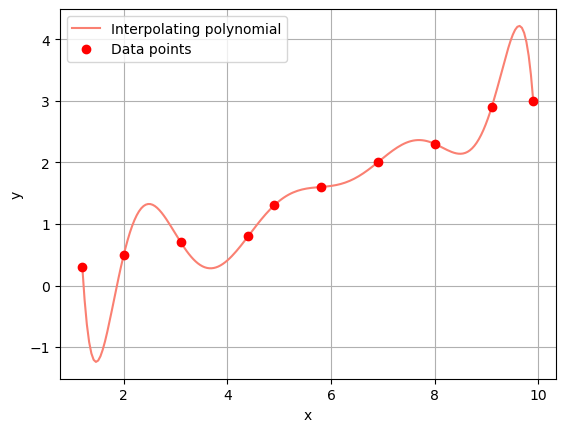

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# Setting all data points
x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

n = len(x)                     # number of points
degree = n - 1                 # polynomial degree = n-1

# We generate a new matrix V (n x n)
V = np.zeros((n, n))
for i in range(n):             # loop over rows (data points)
    for j in range(n):         # loop over columns (powers of x)
        V[i, j] = x[i] ** (n-1-j)    # x[i]**(n-1-j) (from formula x1 + x2**1 + x3**2 + ...)

# Then we solve V * coeff = y  for the polynomial coefficients
coeff = np.linalg.solve(V, y)   # Using the np.linalg.solve() function

# Now I valuate the polynomial for plotting
x_plot = np.linspace(min(x), max(x), 200) 
y_plot = np.zeros_like(x_plot)

# Evaluate polynomial at each x_plot value loops
for i in range(len(x_plot)):
    total = 0.0
    for j in range(n):                     # sum over powers
        total += coeff[j] * (x_plot[i] ** (n-1-j))
    y_plot[i] = total

# Plot
fig = plt.figure()
frame = fig.add_subplot(1, 1, 1)
frame.plot(x_plot, y_plot, 'salmon', label='Interpolating polynomial')
frame.plot(x, y, 'ro', label='Data points')
frame.set_xlabel('x')
frame.set_ylabel('y')
frame.legend()
frame.grid()

### Question 7.6 : Cubic splines and OOP

Use function interp1d() with argument kind='cubic' to find the cubic spline that goes through all these data points.

1. Make a plot of both the data and interpolating spline.
 
2. We mentioned that this is a superior choice than the polynomial interpolation. Compared to the plot you make in Question 7.5, share your thought.

3. Create a object oriented code called interpolation. With inputs x and y, this object can provide interpolation functions of (1) linear, (2) polynomial, and (3) spline interpolation.

4. In this object, create another function that allows user inputs any X^- within the range of x, and one of the arguments for this function allow user to choose which interpolation functions to use for interpolation.

5. Use this function to calculate the corresponding Y^- using linear, polynomial, and spline interpolation.



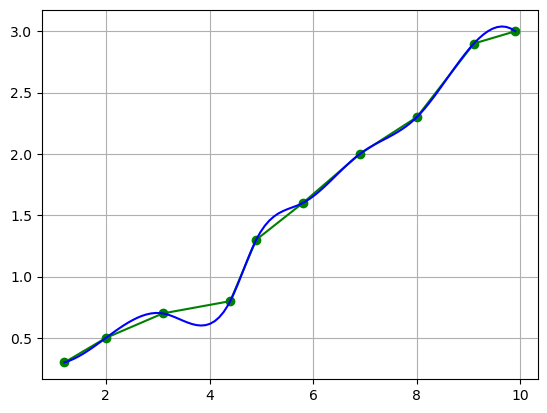

In question 7.5 we can see that the code I used is made manually and the
interpolated polynomialis less accurate than the resulting one for 7.6, 
 which is made automatically by the function ip.interp1d()


x: 5
Enter method you want to use: linear


Linear interpolation at x = 5.0 is 1.3333
Y=1.3333333333333333


In [10]:
import numpy as np
from matplotlib.pyplot import figure, show
from scipy import interpolate as ip

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

# ------------- 1. Make a plot of both the data and interpolating spline. ----------------
f = ip.interp1d(x, y, kind='cubic')

newx = np.linspace(min(x),max(x),100)  # notice outside the original domain
newy = f(newx)

fig = figure()
frame = fig.add_subplot(1,1,1)
frame.plot(x, y, 'go')
frame.plot(x, y, 'g')
frame.plot(newx, newy, 'b')
frame.grid(True)
show()

# ------------- 2. Compared to the plot you make in Question 7.5, share your thought. ----------------
print("In question 7.5 we can see that the code I used is made manually and the")
print("interpolated polynomialis less accurate than the resulting one for 7.6, \n which is made automatically by the function ip.interp1d()")

# ------------- 3. Create a object oriented code called interpolation. With inputs x and y,--------------------------
# ----- this object can provide interpolation functions of (1) linear, (2) polynomial, and (3) spline interpolation.-

class interpolation:
    def __init__(self, x, y):
       self.x = np.array(x)
       self.y = np.array(y)
       self.n = len(x)

    def linear(self, newx):
        for i in range(self.n-1):
            if self.x[i] <= newx <= self.x[i+1]:
                x1, x2 = self.x[i], self.x[i+1]
                y1, y2 = self.y[i], self.y[i+1]
                return y1 + (y2-y1)*(newx - x1)/(x2-x1)
                
    def polynomial(self, newx):
        A = np.zeros((self.n, self.n))
    
        for i in range (self.n):
            for j in range (self.n):
                A[i, j] = self.x[i] **(self.n-1-j)
                
        coeff = np.linalg.solve(A, self.y)
        newy = 0

        for j in range(self.n):
            newy += coeff[j]*(newx**(self.n-1-j))
        return newy

        
    def spline(self, newx):
        f = ip.interp1d(self.x, self.y, kind='cubic')
        newy = f(newx)
        return newy
        
    def Method(self):

        newx = float(input('x:'))
        method = input('Enter method you want to use:')

        linear_y = self.linear(newx)
        polynomial_y = self.polynomial(newx)
        spline_y = self.spline(newx)
        
        if method == "linear":
             result = self.linear(newx)
             print(f'Linear interpolation at x = {newx} is {result:.4f}')
             print(f'Y={linear_y}')
        elif method =='polynomial':
             result = self.polynomial(newx)
             print(f'Polynomial interpolation at x = {newx} is {result:.4f}')
             print(f'Y={polynomial_y}')
        elif method == 'spline':
             result = self.spline(newx)
             print(f'Spline interpolation at x = {newx} is {result:.4f}')
             print(f'Y={spline_y}')
        else:
             print('method not recognized')
             
x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

interp = interpolation(x, y)
interp.Method()

# ------------- 4. Make a plot of both the data and interpolating spline. ----------------
# ------------- 5. Make a plot of both the data and interpolating spline. ----------------

### Question 7.7 : Bilinear interpolation

In section 32.2 of this notebook you can find a formula that calculate the interpolated intensity in a rectangular grid of 4 pixel values.

Copy this formula and add it in your notebook.

Use the formula to find an interpolated intensity of I = np.array([[2.0,4.1], [2.5,3.8]]) at position x=0.2, y=0.7.



In [72]:
import numpy as np

def bilinearIP(I, col, row): # Make it X, Y compatible
    '''I is a two dimensional array and iF,jF is the position at 
       which we want to interpolate. 'iF' must be bigger or equal to 0 and 
       smaller than the highest index of I in i. The same applies for jF'''
    rowlen, collen= I.shape
    i = int(row)
    j = int(col)
    if row - i == 0 and col - j == 0:  # Falls exactly on a gridpoint
        return I[i,j]
    
    inbounds = (0 <= j <= collen-1) and (0 <= i <= rowlen-1)
    if not inbounds:
        Iintp = None
    else:        
        mu =  row - i
        Lambda = col - j
        # If we are at the last pixel at the right or bottom, then there
        # is not a neighbour, so we take the pixel itself as the neighbour
        I0 = I[i,j]
        I1 = I[i,min(j+1,collen-1)]
        I2 = I[min(i+1,rowlen-1),j]
        I3 = I[min(i+1,rowlen-1),min(j+1,collen-1)]  
        Iintp = (1-Lambda)*(1-mu)*I0 + Lambda*(1-mu)*I1 + mu*(1-Lambda)*I2 + Lambda*mu*I3
    return(Iintp)
I = np.array([[2.0,4.1], [2.5,3.8]]) 
print(I)

row_y = 0.7 # Row position is y value
col_x = 0.2  # Column position is x value

Iintp = bilinearIP(I, col_x, row_y)
if Iintp:
    print(f"The interpolated intensity at (i,j)=({row_y},{col_x}) => (x, y)=({col_x},{row_y}) is {Iintp:.6f}")
else: 
    print("One of the indices was outside the limits")

[[2.  4.1]
 [2.5 3.8]]
The interpolated intensity at (i,j)=(0.7,0.2) => (x, y)=(0.2,0.7) is 2.658000


## 7.5. Introduction to model parameter fitting

### Question 7.10 : Fitting the Lemaitre-Hubble relation

Recall week 3, you have practiced to find the parameters of the Hubble law, which is a linear relationship. In this exercise, we will assume a linear relation: y = ax+b for the Hubble's law again, and request you to use scipy.optimize.leastsq() and scipy.optimize.curve_fit() to find the best-fitted parameters for this linear relationship. 

The measured distances (Mpc) and velocities (km/s), including their uncertainties, from an observer, are listed below. 

1. Follow the instruction in the notebook and use scipy.optimize.leastsq() with the consideration of velocity uncertainties to find the most optimal parameters. 

2. Look it up (online and notebook) to use scipy.optimize.curve_fit() with the consideration of velocity uncertainties to find the most optimal parameters.

3. Create a plot with these data points as markers, choose a marker different from the default.

4. Then, plot both relationships on the same plots and write the relationship in their labels.

Results from leastsq:
a = 69.93805978577763
b = 64.13233494072705

Results from curve_fit:
a = 69.9377803016813
b = 64.13234247590542


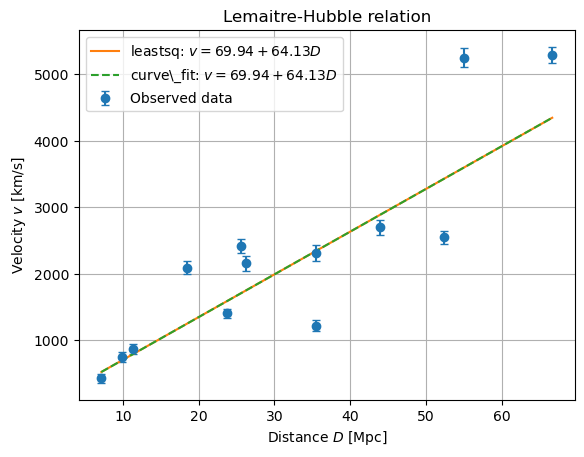

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import leastsq, curve_fit

# STORING THE DATA
# [distance D, velocity v, uncertainty in v]
data = np.array([           # Making it into a numpy array
    [18.49, 2094.75, 100],
    [35.48, 2320.87, 120],
    [35.48, 1224.9, 80],
    [11.34, 872.13, 80],
    [7.12, 432.2, 70],
    [9.82, 751, 75],
    [23.66, 1410, 70],
    [44, 2700, 110],
    [66.7, 5292, 120],
    [52.4, 2550, 100],
    [55, 5253, 150],
    [25.6, 2419, 110],
    [26.19, 2158, 110]
])

# Extracting the columns we need
D = data[:, 0]     # distances (in x axis)
v = data[:, 1]     # velocities (in y axis)
err_v = data[:, 2]   # uncertainty in velocity


# DEFINING THE MODEL FUNCTION
# the model we want to fit: v = a + bD

def model(D, a, b):
    return a + b * D

# 4. METHOD 1: LEASTSQ
# leastsq needs a "residual function"
# residual = (data - model) / error
# We divide by error to include uncertainties

def residuals(params, D, v, err_v):
    a, b = params
    return (v - model(D, a, b)) / err_v

# Initial guess
initial_guess = [0, 70]

# Run least squares
params_leastsq, _ = leastsq(residuals, initial_guess, args=(D, v, err_v))

# Extract fitted parameters
a_ls, b_ls = params_leastsq

# Results
print("Results from leastsq:")
print("a =", a_ls)
print("b =", b_ls)


# 5. METHOD 2: CURVE_FIT
# sigma=err tells the function about uncertainties
params_cf, covariance = curve_fit(model, D, v, sigma=err_v)

# Extract parameters
a_cf, b_cf = params_cf

# CREATING THE SMOOTH LINE FOR PLOTTING

D_line = np.linspace(min(D), max(D), 100)

v_ls = model(D_line, a_ls, b_ls)
v_cf = model(D_line, a_cf, b_cf)

# Results 
print("\nResults from curve_fit:")
print("a =", a_cf)
print("b =", b_cf)

# PLOTTING EVERYTHING
plt.figure()
plt.errorbar(D, v,yerr=err_v,fmt='o',capsize=3,label='Observed data')      # <-- ERROR BARS
                                                                           # fmt = marker style 
plt.plot(D_line, v_ls, label=rf'leastsq: $v = {a_ls:.2f} + {b_ls:.2f}D$')  # <-- leastsq result 

plt.plot(D_line, v_cf,linestyle='--',label=rf'curve\_fit: $v = {a_cf:.2f} + {b_cf:.2f}D$')# <-- curve_fit result

plt.title(r'Lemaitre-Hubble relation')    # Labels and formatting
plt.xlabel(r'Distance $D$ [Mpc]')
plt.ylabel(r'Velocity $v$ [km/s]')
plt.legend()
plt.grid()
plt.show()

Results from leastsq:
a = 69.93805978577763
b = 64.13233494072705
Results from curve fitting:
a = 69.9377803016813
b = 64.13234247590542


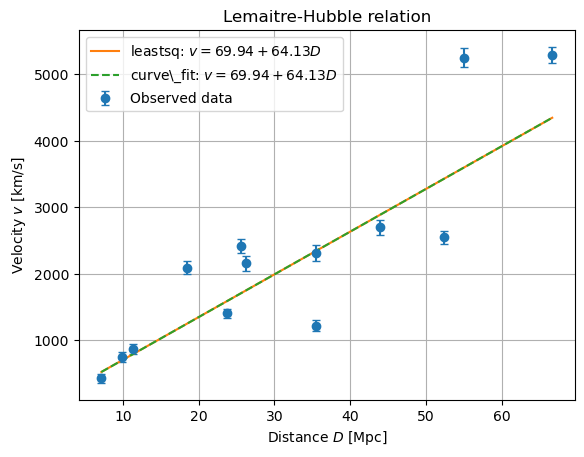

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import leastsq, curve_fit

# STORING THE DATA
# [distance D, velocity v, uncertainty in v]
data = np.array([           # Making it into a numpy array
    [18.49, 2094.75, 100],
    [35.48, 2320.87, 120],
    [35.48, 1224.9, 80],
    [11.34, 872.13, 80],
    [7.12, 432.2, 70],
    [9.82, 751, 75],
    [23.66, 1410, 70],
    [44, 2700, 110],
    [66.7, 5292, 120],
    [52.4, 2550, 100],
    [55, 5253, 150],
    [25.6, 2419, 110],
    [26.19, 2158, 110]
])

# Extracting the columns we need
D = data[:, 0]     # distances (in x axis)
v = data[:, 1]     # velocities (in y axis)
err_v = data[:, 2]   # uncertainty in velocity


# DEFINING THE MODEL FUNCTION
# the model we want to fit: v = a + bD
def model(D, a, b):
    return a + b * D

# LEAST SQUARES
# leastsq needs a "residual function" --> residual = (data - model) / error
def residuals(params, D, v, err_v):
    a, b = params
    return (v - model(D, a, b)) / err_v  # We divide by error to include uncertainties

# Initial guess
initial_guess = [0, 70]

# Running least squares
params_leastsq, _ = leastsq(residuals, initial_guess, args=(D, v, err_v))

# Curve fitting
params_cf, cov = curve_fit(model, D, v, sigma=err_v)

# Extracting fitted parameters
a_ls, b_ls = params_leastsq   # a_ls intercept and b_ls slope
a_cf, b_cf = params_cf

# Results
print("Results from leastsq:")
print("a =", a_ls)
print("b =", b_ls)

print("Results from curve fitting:")
print("a =", a_cf)
print("b =", b_cf)

D_line = np.linspace(min(D), max(D), 100)

# Defining all these parameters in the model function
v_ls = model(D_line, a_ls, b_ls)
v_cf = model(D_line, a_cf, b_cf)


# PLOTTING EVERYTHING
plt.figure()
plt.errorbar(D, v, yerr=err_v , fmt='o',capsize=3,label='Observed data')      # <-- ERROR BARS
                                                                           # fmt = marker style 
plt.plot(D_line, v_ls, label=f'leastsq: $v = {a_ls:.2f} + {b_ls:.2f}D$')  # <-- leastsq result 

plt.plot(D_line, v_cf, linestyle='--',label=f'curve\_fit: $v = {a_cf:.2f} + {b_cf:.2f}D$')  # <-- curve_fit result
plt.title(r'Lemaitre-Hubble relation')   
plt.xlabel(r'Distance $D$ [Mpc]')
plt.ylabel(r'Velocity $v$ [km/s]')
plt.legend()
plt.grid()
plt.show()


## 7.9. Introduction to GitHub Branches

### Question 7.14 :